# Cointegration Testing

Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

### Step 1: Define formation window and extract data
We will define 2016-01-01 as the end of the formation window and extract the previous 2 years of trading data (504 trading days).

In [2]:
formation_end = pd.Timestamp("2016-01-01")
window_size = 504

In [3]:
data_folder_path = Path("data")

membership_file_path = data_folder_path / "membership_df.csv"

Extract list of S&P tickers at formation end

In [4]:
formatted_date = formation_end.strftime('%Y%m')
membership_df = pd.read_csv(membership_file_path)
end_membership = membership_df[formatted_date].dropna().to_list()

Get price data for window

In [5]:
historical_ohlcv_df = pd.read_parquet(data_folder_path / "historical_ohlcv_df.parquet")

Extract data in formation window

In [6]:
formation_data = historical_ohlcv_df.loc[
    historical_ohlcv_df.index < formation_end
].tail(window_size)

Keep only tickers present at formation end

In [7]:
formation_data = formation_data.loc[:, formation_data.columns.get_level_values(0).isin(end_membership)]

Extract close prices for cointegration

In [8]:
formation_close_df = formation_data.xs('Close', axis=1, level=1)

Get number of columns before removing any

In [9]:
num_cols_before = len(formation_close_df.columns)
print(num_cols_before)

508


Remove columns where <= 90% of the expected observation data is present

In [10]:
min_observations = int(len(formation_close_df) * 0.90)

formation_close_df = formation_close_df.dropna(
    axis=1,
    thresh=min_observations
)

In [11]:
num_cols_after = len(formation_close_df.columns.tolist())
print(f"{num_cols_after/num_cols_before:.2%} of columns remain after dropping columns with less than {min_observations} observations.")

77.56% of columns remain after dropping columns with less than 453 observations.


### Step 2: Filter uncorrelated pairs before cointegration testing

Calculate percent changes in closing prices from one trading day to another

In [12]:
returns = formation_close_df.pct_change().dropna()

In [13]:
correlation_matrix = returns.corr()

Select for only pairs where correlation > 0.7. We will only perform cointegration testing on this correlated set.

In [14]:
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)) # select upper triangle since matrix is symmetric; ensure no duplicates pairs are considered
high_corr_pairs = (upper_triangle.stack().loc[lambda x: x > 0.7])
filtered_pairs = high_corr_pairs.index.tolist()
print(len(filtered_pairs))

794


Perform cointegration testing on filtered pairs

In [15]:
log_prices = np.log(formation_close_df)
threshold = 0.05 # select the significance level for the cointegration test
cointegrated_pairs = []
for pair in filtered_pairs:
    ticker_0, ticker_1 = pair
    log_pair_prices = log_prices[[pair[0], pair[1]]]
    coint_t, p_value, critical_values = coint(log_prices[ticker_0], log_prices[ticker_1])
    if p_value < threshold:
        cointegrated_pairs.append(pair)

print("Cointegrated pairs:", len(cointegrated_pairs))

Cointegrated pairs: 108


### Step 3: Perform these calculations while sliding the window

Create a function to perform these calculations for a given window

In [16]:
# Note: do not apply significance filtering here.
# We need all cointegration-test p-values for Benjamini-Hochberg correction later.
def test_cointegration_window(formation_end, window_size=504, obs_threshold = 0.90, corr_threshold=0.7):
    formation_data = historical_ohlcv_df.loc[
        historical_ohlcv_df.index < formation_end
    ].tail(window_size)

    formatted_date = formation_end.strftime('%Y%m')
    end_membership = membership_df[formatted_date].dropna().to_list()
    formation_data = formation_data.loc[:, formation_data.columns.get_level_values(0).isin(end_membership)]

    formation_close_df = formation_data.xs('Close', axis=1, level=1)
    
    min_observations = int(len(formation_close_df) * obs_threshold)

    formation_close_df = formation_close_df.dropna(
        axis=1,
        thresh=min_observations
    )

    # Correlation filtering
    returns = formation_close_df.pct_change(fill_method=None)
    correlation_matrix = returns.corr()

    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)) # select upper triangle since matrix is symmetric; ensure no duplicates pairs are considered
    high_corr_pairs = (upper_triangle.stack().loc[lambda x: x > corr_threshold])
    filtered_pairs = high_corr_pairs.index.tolist()

    # Cointegration testing
    coint_results = []

    for ticker_0, ticker_1 in filtered_pairs:
        pair_prices = formation_close_df[[ticker_0, ticker_1]].dropna()

        coint_t, p_value, critical_values = coint(
            pair_prices[ticker_0],
            pair_prices[ticker_1]
        )

        coint_results.append({
            "formation_end": formation_end,
            "ticker_0": ticker_0,
            "ticker_1": ticker_1,
            "correlation": correlation_matrix.loc[ticker_0, ticker_1],
            "coint_t": coint_t,
            "p_value": p_value,
            "critical_1pct": critical_values[0],
            "critical_5pct": critical_values[1],
            "critical_10pct": critical_values[2],
            "n_observations": len(pair_prices)
        })

    return pd.DataFrame(coint_results)

Testing function

In [17]:
results = test_cointegration_window(pd.Timestamp("2016-01-01"))

results.head()

,formation_end,ticker_0,ticker_1,correlation,coint_t,p_value,critical_1pct,critical_5pct,critical_10pct,n_observations
0,2016-01-01,RF,LNC,0.780918,-3.229933,0.065063,-3.918346,-3.348304,-3.052893,504
1,2016-01-01,RF,PNC,0.838191,-3.245737,0.062606,-3.918346,-3.348304,-3.052893,504
2,2016-01-01,RF,AMP,0.718768,-3.594219,0.024908,-3.918346,-3.348304,-3.052893,504
3,2016-01-01,RF,USB,0.811633,-3.126354,0.083131,-3.918346,-3.348304,-3.052893,504
4,2016-01-01,RF,PFG,0.710393,-3.309604,0.053430,-3.918346,-3.348304,-3.052893,504


Execute this function while sliding the window

In [18]:
formation_end = pd.Timestamp("2016-01-01")
final_date = pd.Timestamp("2026-01-01")

results = []
while formation_end <= final_date:
    results.append(test_cointegration_window(formation_end))
    formation_end += pd.DateOffset(months=1) # offset by one month (unlikely to use a trading window smaller than this)

all_results = pd.concat(results, ignore_index=True)

all_results = all_results.set_index(['formation_end', 'ticker_0', 'ticker_1'])

In [19]:
all_results.to_parquet(data_folder_path / "cointegration_results.parquet")

Analyze results with significance filtering.

In [20]:
sig_results = all_results[all_results["p_value"] < 0.05] # threshold = 0.05

In [21]:
sig_results.to_parquet(data_folder_path / "sig_results.parquet")

View stats on pairs that met the significance threshold

In [22]:
# Since window size is constant, we identify a window by the month of its formation end date.
pairs_per_month = sig_results.groupby(level="formation_end").size()

pairs_per_month.describe()

count    121.000000
mean     119.173554
std      133.944496
min       19.000000
25%       43.000000
50%       72.000000
75%      101.000000
max      837.000000
dtype: float64

The max is significantly greater than the average number of pairs. Plot the number of significant pairs per formation window over time to visually inspect this result.

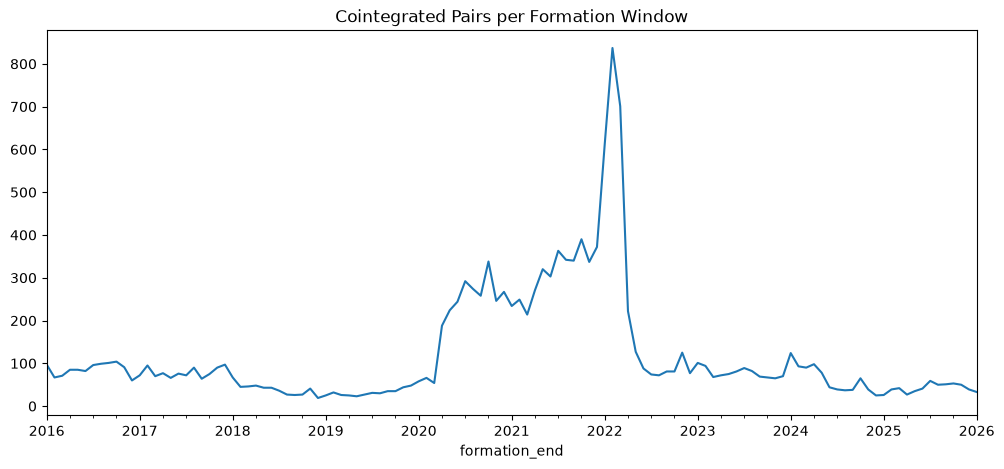

In [29]:
ax = pairs_per_month.plot(title="Cointegrated Pairs per Formation Window", figsize=(12, 5))
ax.get_figure().savefig("assets/raw_cointegrated_pairs")

Based on this graph, it seems plausible that market conditions during the COVID-19 pandemic caused several S&P 500 pairs to temporarily appear more cointegrated. This suggests that using a correction method like the Benjamini-Hochberg Procedure may be appropriate to limit the number of false discoveries. We will implement this with a target false discovery rate of 0.05.

Define a function to apply Benjamini-Hochberg correction to a group of p-values

In [24]:
def apply_bh(group):
    reject, p_adj, _, _ = multipletests(group["p_value"], alpha=0.05, method='fdr_bh')
    group = group.copy()
    group["bh_reject"] = reject
    group["bh_p_value"] = p_adj
    return group

Apply this function to each formation window group

In [25]:
all_results_bh = all_results.groupby(level="formation_end", group_keys=False).apply(apply_bh)

Save to parquet

In [26]:
all_results_bh.to_parquet(data_folder_path / "bh_corrected_results.parquet")

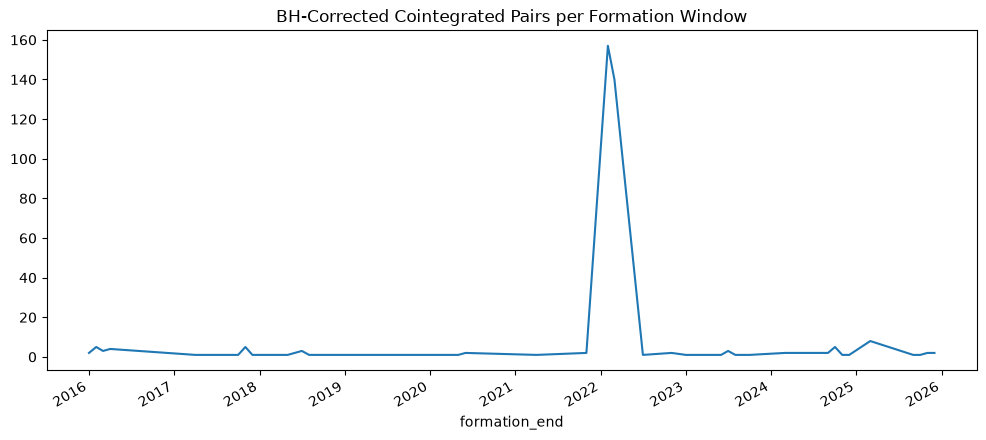

In [28]:
pairs_per_month_bh = all_results_bh[all_results_bh['bh_reject']].groupby(level="formation_end").size()
ax = pairs_per_month_bh.plot(title="BH-Corrected Cointegrated Pairs per Formation Window", figsize=(12, 5))
ax.get_figure().savefig("assets/bh_cointegrated_pairs")

The results after BH correction are somewhat unusual. For most windows, very few pairs survived correction, but there is a dramatic spike in early 2022. It is not immediately clear whether this is primarily due to market conditions, properties of the cointegration test, or a feature of the screening process. Rather than investigating this further, I will perform backtesting using both the raw significance-threshold set and the BH-corrected set and compare their results.